In [2]:
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

2024-06-15 01:05:07.454247: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-15 01:05:09.017796: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [15]:
keras.__version__

'3.3.3'

In [16]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [17]:
X_train.shape

(60000, 28, 28)

In [18]:
X_train.dtype

dtype('uint8')

In [19]:
X_valid, X_train = X_train[:5000], X_train[5000:]
y_valid, y_train = y_train[:5000], y_train[5000:]

In [20]:
X_train.shape 

(55000, 28, 28)

In [21]:
y_train.shape

(55000,)

In [22]:
X_val.shape

(5000, 28, 28)

In [23]:
y_val.shape

(5000,)

In [24]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_valid = X_valid.astype('float32')/255.0

In [25]:
y_train = y_train.astype(int)/255.0
y_test = y_test.astype(int)/255.0
y_valid= y_valid.astype(int)/255.0

In [26]:
print(f"Valores de x_train: mínimo = {X_train.min()}, máximo = {X_train.max()}")
print(f"Valores de x_val: mínimo = {X_val.min()}, máximo = {X_val.max()}")
print(f"Valores de x_test: mínimo = {X_test.min()}, máximo = {X_test.max()}")

Valores de x_train: mínimo = 0.0, máximo = 1.0
Valores de x_val: mínimo = 0.0, máximo = 1.0
Valores de x_test: mínimo = 0.0, máximo = 1.0


In [27]:
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal",
"Shirt", "Sneaker", "Bag", "Ankle boot"]

In [28]:
model = keras.models.Sequential([layers.Flatten(input_shape=(28, 28)),        # Flatten the input images (28x28) into 1D vectors
    layers.Dense(128, activation='relu'),        # Hidden layer with 128 neurons and ReLU activation
    layers.Dropout(0.2),                         # Dropout layer for regularization (dropout rate 20%)
    layers.Dense(10, activation='softmax')])

/home/mike/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2024-06-15 01:05:47.484744: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-15 01:05:47.898944: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Sk

In [29]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [30]:
history = model.fit(X_train, y_train, epochs=30, validation_data=[X_val, y_val])

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1005 - loss: 0.0185 - val_accuracy: 0.0914 - val_loss: 53.6122
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1002 - loss: 5.0100e-06 - val_accuracy: 0.0914 - val_loss: 66.2410
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0997 - loss: 1.1937e-06 - val_accuracy: 0.0914 - val_loss: 74.2366
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1009 - loss: 4.3701e-07 - val_accuracy: 0.0914 - val_loss: 83.2354
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1000 - loss: 2.6753e-07 - val_accuracy: 0.0914 - val_loss: 89.4684
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1005 - loss: 1.8514e-08 - val_accuracy: 0.0914 - val_loss: 93.2630
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0986 - loss: 4.3771e-08 - val_accuracy: 0.0914 - val_loss: 104.3605
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - ac

In [31]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisão no conjunto de teste: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1001 - loss: 0.0000e+00
Precisão no conjunto de teste: 0.1000


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [33]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()
print(f"Pesos da primeira camada escondida: {weights.shape}")
print(f"Biases da primeira camada escondida: {biases.shape}")

Pesos da primeira camada escondida: (784, 128)
Biases da primeira camada escondida: (128,)


In [34]:
new_weights = np.random.rand(weights.shape[0], weights.shape[1])
new_biases = np.random.rand(biases.shape[0])
hidden1.set_weights([new_weights, new_biases])

In [35]:
from tensorflow.keras.optimizers import SGD

# Exemplo de definição do otimizador SGD
optimizer = SGD(learning_rate=0.01, momentum=0.9)

In [36]:
from tensorflow.keras.losses import sparse_categorical_crossentropy

# Exemplo de uso da função de perda na compilação do modelo
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [37]:
print("Parâmetros de treino:", history.params)
print("Lista de épocas:", history.epoch)
print("Histórico de treino:", history.history)

Parâmetros de treino: {'verbose': 'auto', 'epochs': 30, 'steps': 1719}
Lista de épocas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Histórico de treino: {'accuracy': [0.10069090873003006, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372, 0.10078182071447372], 'loss': [0.0025708090979605913, 3.8858897823956795e-06, 1.006155002869491e-06, 4.3143083416907757e-07, 1.868812091743166e-07, 2.3428263

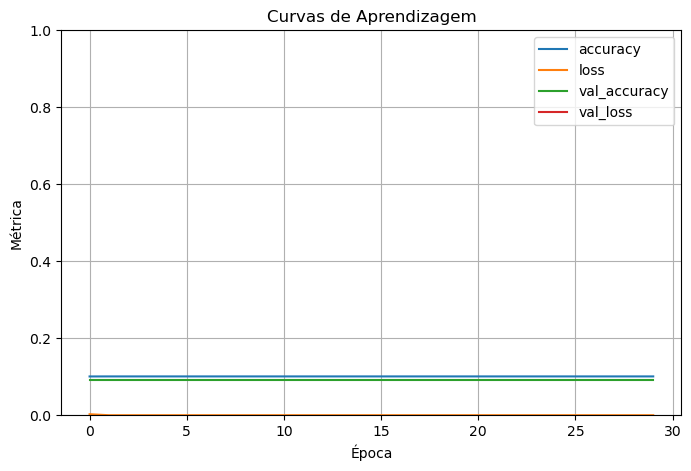

In [38]:
import pandas as pd
history_df = pd.DataFrame(history.history)

# Plotar as curvas de aprendizagem
history_df.plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)  # Definir limites para o eixo y
plt.title("Curvas de Aprendizagem")
plt.xlabel("Época")
plt.ylabel("Métrica")
plt.show()

In [39]:
test_loss, test_acc = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1001 - loss: 0.0000e+00


In [40]:
print("Test loss:",test_loss)
print("Test acc", test_acc)

Test loss: 0.0
Test acc 0.10000000149011612


In [43]:
model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.99999994, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)